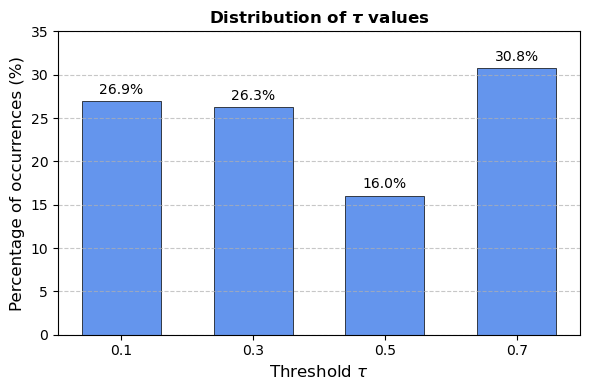

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load threshold frequency data
df = pd.read_csv("threshold_frequency.csv")
df = df.sort_values("threshold")  # ensure order: 0.1, 0.3, 0.5, 0.7

# Plot settings
plt.figure(figsize=(6, 4))
bars = plt.bar(df["threshold"].astype(str), df["percentage"],
               color='cornflowerblue', edgecolor='black', linewidth=0.5, width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel(r'Threshold $\tau$', fontsize=12)
plt.ylabel('Percentage of occurrences (%)', fontsize=12)
plt.title(r'Distribution of $\boldsymbol{\tau}$ values', fontsize=12, fontweight='bold')
plt.ylim(0, 35)   # y starts at 0, extends slightly above max for label space
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='-', alpha=0) #remove x grid lines for clarity

# Save or show
plt.tight_layout()
plt.savefig('threshold_frequency_bar.png', dpi=300)
plt.show()

C:\Users\grobl\AppData\Local\Temp\ipykernel_13980\823927797.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = data.stack(level=[0, 1]).reset_index(name="threshold")


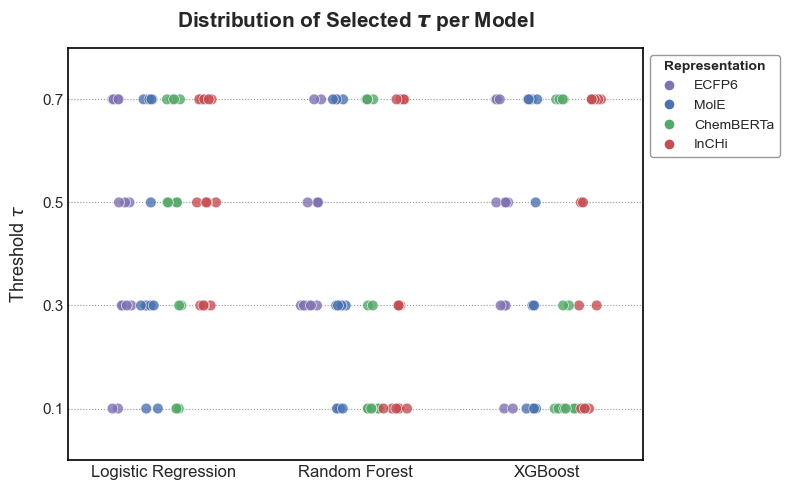

In [3]:
import numpy as np
import matplotlib.ticker as ticker

# ----------------------------------------------------------------------
# 1. Read and parse the messy CSV
# ----------------------------------------------------------------------
df_raw = pd.read_csv("thresholds_pivot.csv", header=None)

# Find the first row whose first cell starts with 'CYP' (case-insensitive)
mask = df_raw.iloc[:, 0].astype(str).str.upper().str.startswith("CYP")
first_data_row = mask.idxmax()

# Extract the real column headers (model + representation)
model_row = df_raw.iloc[0, 1:].astype(str).str.strip().values
repr_row = df_raw.iloc[1, 1:].astype(str).str.strip().values

# Build a MultiIndex for the data columns
columns = pd.MultiIndex.from_arrays([model_row, repr_row],
                                    names=["model", "representation"])

# Create a DataFrame with the numeric data, indexed by CYP name
data = df_raw.iloc[first_data_row:, :].copy()
data.index = data.iloc[:, 0]               # CYP name as index
data.drop(columns=0, inplace=True)         # remove the CYP name column
data.columns = columns                     # assign multi-level column names
data = data.astype(float)

# ----------------------------------------------------------------------
# 2. Reshape to long format (one row per observation)
# ----------------------------------------------------------------------
long = data.stack(level=[0, 1]).reset_index(name="threshold")
# Drop the old CYP index column (first column)
long.drop(long.columns[0], axis=1, inplace=True)
# Now long has columns: model, representation, threshold

# ----------------------------------------------------------------------
# 3. Prepare the plot
# ----------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Black outline
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

# Dotted horizontal reference lines (0.1, 0.3, 0.5, 0.7)
y_ticks = [0.1, 0.3, 0.5, 0.7]
for y in y_ticks:
    ax.axhline(y, color="grey", linestyle="dotted", linewidth=0.8, alpha=0.7)

# Model order on the x-axis
model_order = ["logistic_regression", "random_forest", "xgboost"]
model_labels = ["Logistic Regression", "Random Forest", "XGBoost"]

rep_palette = {
    "morgan":    "#8172B2",   
    "MolE":      "#4C72B0",   
    "chemberta": "#55A868",   
    "inchi":     "#C44E52",   
}

# Desired order for dodging: morgan leftmost, then MolE, chemberta, inchi
rep_order = ["morgan", "MolE", "chemberta", "inchi"]
rep_offset = {rep: (i - 1.5) * 0.15 for i, rep in enumerate(rep_order)}

# Legend display names
display_names = {
    "morgan": "ECFP6",
    "MolE": "MolE",
    "chemberta": "ChemBERTa",
    "inchi": "InCHi"
}

# Small random jitter to separate identical thresholds within a group
jitter_strength = 0.03
np.random.seed(42)

x_positions = []
y_vals = []
colors = []

for i, model in enumerate(model_order):
    subset = long[long["model"] == model]
    centre = i + 1
    for _, row in subset.iterrows():
        rep = row["representation"]
        base_x = centre + rep_offset[rep]
        x_jitter = base_x + np.random.normal(0, jitter_strength)
        x_positions.append(x_jitter)
        y_vals.append(row["threshold"])
        colors.append(rep_palette[rep])

ax.scatter(x_positions, y_vals, c=colors, alpha=0.8, edgecolors="white",
           linewidth=0.5, s=60, zorder=3)

# ----------------------------------------------------------------------
# 4. Axis formatting
# ----------------------------------------------------------------------
ax.set_xlim(0.5, len(model_order) + 0.5)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(model_labels, fontsize=12)

ax.set_ylim(0, 0.8)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{y:.1f}" for y in y_ticks], fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

ax.tick_params(axis="y", which="minor", left=False)
ax.grid(True, which="major", axis="y", color="#DCDCDC", linestyle="dotted", linewidth=0.8)
ax.grid(False, axis="x")

# Y-axis label with LaTeX tau
ax.set_ylabel(r'Threshold $\tau$', fontsize=13, labelpad=10)
# Title using tau symbol
ax.set_title(r'Distribution of Selected $\boldsymbol{\tau}$ per Model',
             fontsize=15, pad=15, fontweight="bold")

# Legend – iterate over rep_order to match the visual order
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=rep_palette[rep],
               markersize=8, label=display_names[rep])
    for rep in rep_order
]
ax.legend(handles=handles, title="Representation", 
          loc="upper left", bbox_to_anchor=(1, 1), frameon=True,
          facecolor="white", edgecolor="grey",
          title_fontproperties={'weight': 'bold'})

plt.tight_layout()
plt.savefig('threshold_distribution_permodel.png', dpi=300)
plt.show()

C:\Users\grobl\AppData\Local\Temp\ipykernel_13980\1935219298.py:26: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  raw_long = data.stack(level=[0, 1]).reset_index(name="threshold")


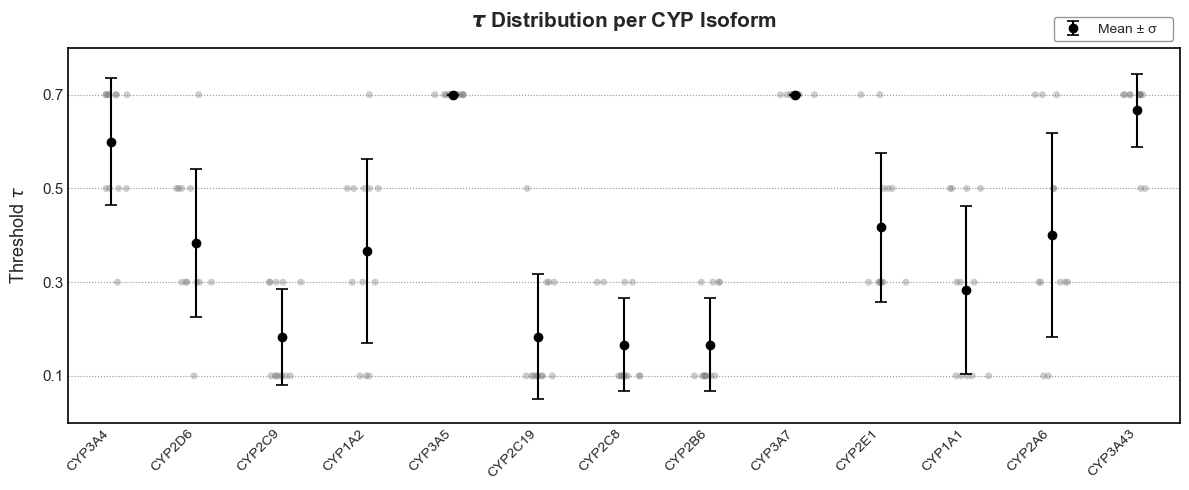

In [4]:
# ----------------------------------------------------------------------
# 1. Read raw thresholds (keeping CYP names)
# ----------------------------------------------------------------------
df_raw = pd.read_csv("thresholds_pivot.csv", header=None)

# Locate first CYP data row
mask = df_raw.iloc[:, 0].astype(str).str.upper().str.startswith("CYP")
first_data_row = mask.idxmax()

# Extract headers
model_row = df_raw.iloc[0, 1:].astype(str).str.strip().values
repr_row = df_raw.iloc[1, 1:].astype(str).str.strip().values

# Build MultiIndex columns
columns = pd.MultiIndex.from_arrays([model_row, repr_row],
                                    names=["model", "representation"])

# Create data DataFrame, keeping CYP as index
data = df_raw.iloc[first_data_row:, :].copy()
data.index = data.iloc[:, 0]                # CYP name as index
data.drop(columns=0, inplace=True)          # remove CYP column from data
data.columns = columns
data = data.astype(float)

# Stack to long format, keep CYP in a column
raw_long = data.stack(level=[0, 1]).reset_index(name="threshold")
raw_long.rename(columns={raw_long.columns[0]: "CYP"}, inplace=True)
# Now raw_long has: CYP, model, representation, threshold

# ----------------------------------------------------------------------
# 2. Read summary statistics
# ----------------------------------------------------------------------
summary = pd.read_csv("threshold_summary.csv")
summary.rename(columns={"cyp": "CYP"}, inplace=True)

# Ensure CYP names match (uppercase)
summary["CYP"] = summary["CYP"].str.upper()

# ----------------------------------------------------------------------
# 3. Prepare plot
# ----------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Black axis outline
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

# Dotted horizontal reference lines
y_ticks = [0.1, 0.3, 0.5, 0.7]
for y in y_ticks:
    ax.axhline(y, color="grey", linestyle="dotted", linewidth=0.8, alpha=0.7)

# CYP order (from summary)
cyp_order = summary["CYP"].tolist()
x_positions = range(len(cyp_order))

# Jitter parameters for raw points
jitter_strength = 0.12
np.random.seed(42)

# Plot raw thresholds as gray jittered dots
for i, cyp in enumerate(cyp_order):
    cyp_data = raw_long[raw_long["CYP"] == cyp]
    if not cyp_data.empty:
        # Jitter x
        x_jit = i + np.random.normal(0, jitter_strength, size=len(cyp_data))
        ax.scatter(x_jit, cyp_data["threshold"],
                   color="gray", alpha=0.4, s=25, zorder=2,
                   edgecolors="none", label="__nolegend__")

# Plot mean ± std on top
for i, row in summary.iterrows():
    cyp = row["CYP"]
    x = i  # integer x-position
    mean_val = row["mean_threshold"]
    std_val = row["std_threshold"]
    ax.errorbar(x, mean_val, yerr=std_val,
                fmt='o', color='black', capsize=4, capthick=1.2,
                markersize=6, zorder=3, linewidth=1.5,
                label="Mean ± σ" if i == 0 else "")

# ----------------------------------------------------------------------
# 4. Axis formatting
# ----------------------------------------------------------------------
ax.set_xticks(list(x_positions))
ax.set_xticklabels(cyp_order, rotation=45, ha="right", fontsize=10)
ax.set_xlim(-0.5, len(cyp_order) - 0.5)

ax.set_ylim(0, 0.8)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{y:.1f}" for y in y_ticks], fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

ax.tick_params(axis="y", which="minor", left=False)
ax.grid(True, which="major", axis="y", color="#DCDCDC", linestyle="dotted", linewidth=0.8)
ax.grid(False, axis="x")

# Labels & title
ax.set_ylabel(r'Threshold $\tau$', fontsize=13, labelpad=10)
ax.set_title(r'$\boldsymbol{\tau}$ Distribution per CYP Isoform', fontsize=15, pad=15, fontweight="bold")

#Leave space for legend on the right
plt.subplots_adjust(right=0.85)

ax.legend(loc="upper left", 
          bbox_to_anchor=(0.88, 0.98, 0.12, 0.12), 
          mode="expand", 
          frameon=True, facecolor="white", edgecolor="grey")

plt.tight_layout()
plt.savefig('threshold_distribution_percyp.png', dpi=300)
plt.show()

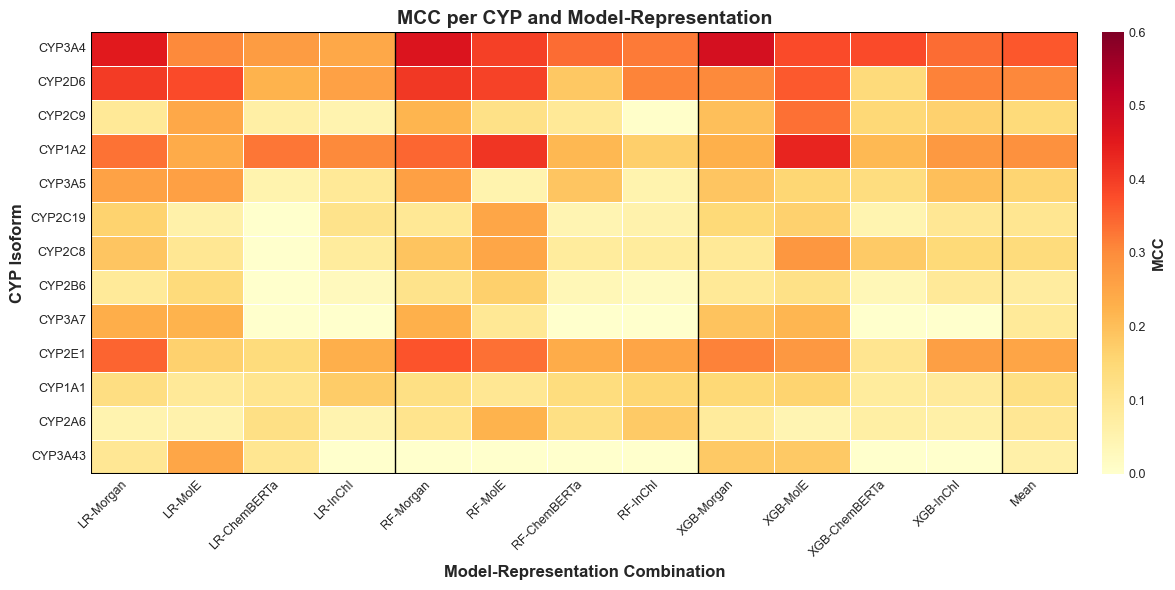

In [5]:
import seaborn as sns

# 1. Read the CSV with multi‑level headers
df_raw = pd.read_csv("per_cyp_mcc_pivot.csv", header=None)

model_row = df_raw.iloc[0, 1:].astype(str).str.strip().values
repr_row = df_raw.iloc[1, 1:].astype(str).str.strip().values

columns = pd.MultiIndex.from_arrays([model_row, repr_row],
                                    names=["model", "representation"])

data = df_raw.iloc[2:, :].copy()
data.index = data.iloc[:, 0].astype(str).str.strip()
data.drop(columns=0, inplace=True)
data.columns = columns
data = data.astype(float)

# 2. Extract the 'mean' column, then drop it from main data
mean_cols = [col for col in data.columns if col[0].lower() == 'mean']
if not mean_cols:
    raise ValueError("No 'mean' column found.")
mean_series = data[mean_cols[0]].rename('Mean')

if data.index.str.lower().isin(['mean']).any():
    data = data.drop(index='mean')
data = data.drop(columns=mean_cols)


# 3. Reorder and flatten columns
model_order = ['logistic_regression', 'random_forest', 'xgboost']
repr_order  = ['morgan', 'MolE', 'chemberta', 'inchi']

model_abbrev = {
    'logistic_regression': 'LR',
    'random_forest':       'RF',
    'xgboost':     'XGB'
}
repr_display = {
    'morgan':    'Morgan',
    'MolE':      'MolE',
    'chemberta': 'ChemBERTa',
    'inchi':     'InChI'
}

ordered_tuples = []
for model in model_order:
    for rep in repr_order:
        if (model, rep) in data.columns:
            ordered_tuples.append((model, rep))

flat_col_names = [
    f"{model_abbrev[model]}-{repr_display[rep]}"
    for model, rep in ordered_tuples
]

heatmap_data = pd.DataFrame(
    data[ordered_tuples].values,
    index=data.index,
    columns=flat_col_names
)
heatmap_data['Mean'] = mean_series


# 4. Draw the heatmap (colour scale 0 – 0.6)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(heatmap_data,
            annot=False,
            cmap='YlOrRd',
            vmin=0, vmax=0.6,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'MCC', 'pad': 0.02})

# --- Thick vertical lines to separate model groups ---
for x_pos in [4, 8, 12]:
    ax.axvline(x=x_pos, color='black', linewidth=1, linestyle='-')

n_rows, n_cols = heatmap_data.shape
ax.axhline(y=0, color='black', linewidth=1.5)
ax.axhline(y=n_rows, color='black', linewidth=1.5)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.axvline(x=n_cols, color='black', linewidth=1.5)

# Axis labels
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(heatmap_data.index, rotation=0, fontsize=9)

ax.set_xlabel("Model-Representation Combination", fontsize=12, fontweight='bold')
ax.set_ylabel("CYP Isoform", fontsize=12, fontweight='bold')
ax.set_title("MCC per CYP and Model-Representation",
             fontsize=14, fontweight='bold')

# Color bar formatting
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label('MCC', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('MCC_Heatmap.png', dpi=300)
plt.show()

In [7]:
import pandas as pd

# ----------------------------------------------------------------------
# 1. Load data
# ----------------------------------------------------------------------
cv_df = pd.read_csv("all_cv_results.csv")
master_df = pd.read_csv("master_results.csv")

# ----------------------------------------------------------------------
# 2. Compute mean and std of CV MCC per (model, representation)
# ----------------------------------------------------------------------
cv_stats = cv_df.groupby(['model', 'representation'])['macro_mcc'].agg(['mean', 'std']).reset_index()
cv_stats.columns = ['model', 'representation', 'mean_cv_mcc', 'std_cv_mcc']

# ----------------------------------------------------------------------
# 3. Merge with test macro MCC from master
# ----------------------------------------------------------------------
summary = pd.merge(cv_stats, master_df[['model', 'representation', 'macro_mcc']],
                   on=['model', 'representation'], how='inner')
summary.rename(columns={'macro_mcc': 'test_macro_mcc'}, inplace=True)

# ----------------------------------------------------------------------
# 4. Compute difference (test - CV mean) – negative = test is worse
# ----------------------------------------------------------------------
summary['difference'] = summary['test_macro_mcc'] - summary['mean_cv_mcc']

# ----------------------------------------------------------------------
# 5. Order rows: first LR, then RF, then XGB; within each, ECFP6/MolE/ChemBERTa/InChI
# ----------------------------------------------------------------------
model_order = ['logistic_regression', 'random_forest', 'xgboost']
repr_order = ['morgan', 'MolE', 'chemberta', 'inchi']

summary['model'] = pd.Categorical(summary['model'], categories=model_order, ordered=True)
summary['representation'] = pd.Categorical(summary['representation'], categories=repr_order, ordered=True)
summary = summary.sort_values(['model', 'representation']).reset_index(drop=True)

# ----------------------------------------------------------------------
# 6. Round for readability
# ----------------------------------------------------------------------
numeric_cols = ['mean_cv_mcc', 'std_cv_mcc', 'test_macro_mcc', 'difference']
summary[numeric_cols] = summary[numeric_cols].round(4)

# ----------------------------------------------------------------------
# 7. Save and display
# ----------------------------------------------------------------------
summary.to_csv("cv_vs_test_summary.csv", index=False)

print("Summary table saved as 'cv_vs_test_summary.csv'")
print("\nTable preview:")
summary

Summary table saved as 'cv_vs_test_summary.csv'

Table preview:


,model,representation,mean_cv_mcc,std_cv_mcc,test_macro_mcc,difference
0,logistic_regression,morgan,0.4437,0.0168,0.2182,-0.2255
1,logistic_regression,MolE,0.4114,0.0365,0.1936,-0.2178
2,logistic_regression,chemberta,0.3713,0.1202,0.1069,-0.2644
3,logistic_regression,inchi,0.4132,0.0361,0.1224,-0.2907
4,random_forest,morgan,0.4704,0.0081,0.2241,-0.2463
5,random_forest,MolE,0.4582,0.0035,0.2138,-0.2444
6,random_forest,chemberta,0.4358,0.0055,0.1292,-0.3066
7,random_forest,inchi,0.4467,0.0026,0.1205,-0.3262
8,xgboost,morgan,0.4589,0.0085,0.2041,-0.2548
9,xgboost,MolE,0.4533,0.0045,0.2396,-0.2136


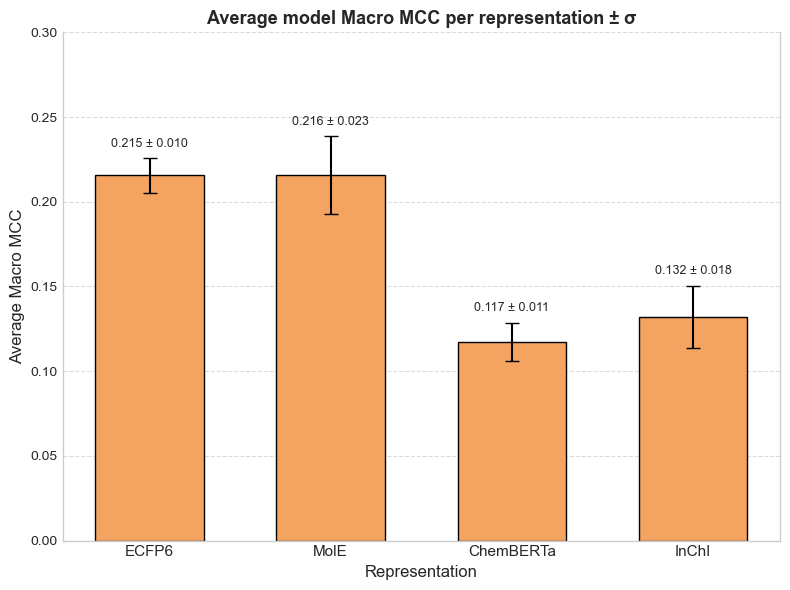

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# Load data
# ----------------------------------------------------------------------
summary_repr = pd.read_csv("summary_by_representation.csv")

# Define the desired order and corresponding labels
order = ['morgan', 'MolE', 'chemberta', 'inchi']
labels = ['ECFP6', 'MolE', 'ChemBERTa', 'InChI']

# Reorder the dataframe
summary_repr['representation'] = pd.Categorical(
    summary_repr['representation'], categories=order, ordered=True
)
summary_repr = summary_repr.sort_values('representation').reset_index(drop=True)

plt.figure(figsize=(8, 6))

bars = plt.bar(
    x=summary_repr['representation'],
    height=summary_repr['mean_macro_mcc'],
    yerr=summary_repr['std_macro_mcc'],
    color='sandybrown',
    edgecolor='black',
    capsize=5,
    width=0.6,
    error_kw={'linewidth': 1.5, 'ecolor': 'black'}
)

# Add value labels above the error bars
for bar, mean, std in zip(bars, summary_repr['mean_macro_mcc'], summary_repr['std_macro_mcc']):
    # Place text at (bar center, mean + std + a small offset)
    y_pos = mean + std + 0.005
    plt.text(bar.get_x() + bar.get_width()/2., y_pos,
             f'{mean:.3f} ± {std:.3f}',
             ha='center', va='bottom', fontsize=9)

# Customise x‑ticks with the desired labels
plt.xticks(ticks=range(len(order)), labels=labels, fontsize=11)

# Labels and title
plt.ylabel('Average Macro MCC', fontsize=12)
plt.xlabel('Representation', fontsize=12)
plt.title('Average model Macro MCC per representation ± σ', fontsize=13, fontweight='bold')
plt.ylim(0, 0.3)   # adjust to leave space for labels
plt.grid(axis='x', linestyle='-', alpha=0) #remove x grid lines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)   # only horizontal grid

# Remove top and right spines
sns.despine(right=False, top=True)

plt.tight_layout()
plt.savefig('macro_mcc_per_representation.png', dpi=300)
plt.show()